<a href="https://colab.research.google.com/github/pavanKarthik2006/Biocomputing/blob/main/Classification_Practice2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.datasets import fetch_openml

X,y=fetch_openml("mnist_784",version=1,return_X_y=True,as_frame=False)
y=y.astype(int)

split_index=int(0.7*len(X))

X_train=X[:split_index]
X_test=X[split_index:]
y_train=y[:split_index]
y_test=y[split_index]

In [2]:
last_training_digit = y_train[-1]
print( last_training_digit)

6


In [3]:
mask_train_69=(y_train==6)|(y_train==9)
X_train_69=X_train[mask_train_69]
y_train_69=y_train[mask_train_69]

In [6]:
import numpy as np
from sklearn.utils import shuffle
y_train_69 = np.where(y_train_69 == 6, 1, 0)

# Step 5–6: Shuffle
X_train_69, y_train_69 = shuffle(X_train_69, y_train_69, random_state=1729)

In [8]:
label_sum = np.sum(y_train_69)
print(label_sum)

0


In [13]:
from sklearn.datasets import fetch_openml
from sklearn.utils import shuffle
import numpy as np

# Load MNIST
X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)
y = y.astype(int)

# Train/test split: 70% train, 30% test
split_idx = int(0.7 * len(X))
x_train_full, y_train_full = X[:split_idx], y[:split_idx]
x_test_full, y_test_full = X[split_idx:], y[split_idx:]

# Step 1–4: Select digits 6 and 9 in training set
mask_train_69 = (y_train_full == 6) | (y_train_full == 9)
mask_test_69=(y_test_full==6)|(y_test_full==9)
x_train_69 = x_train_full[mask_train_69]
y_train_69 = y_train_full[mask_train_69]
y_test_69=y_test_full[mask_test_69]
y_train_69 = np.where(y_train_69 == 6, 1, 0)

# Step 5–6: Shuffle
x_train_69, y_train_69 = shuffle(x_train_69, y_train_69, random_state=1729)

# Final Answer
label_sum = np.sum(y_train_69)
print("Sum of labels in y_train_69:", label_sum)


Sum of labels in y_train_69: 4855


In [14]:
test_sum=np.sum(y_test_69)
print(test_sum)

30729


In [15]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
X_train_69Tf=scaler.fit_transform(X_train_69)

sample_0 = X_train_69Tf[0]
mean_sample_0 = np.mean(sample_0)
std_sample_0 = np.std(sample_0)

feature_0 = X_train_69Tf[:, 0]
mean_feature_0 = np.mean(feature_0)
std_feature_0 = np.std(feature_0)

result=(mean_sample_0,std_sample_0,mean_feature_0,std_feature_0)
print(result)

(np.float64(0.12852248695493249), np.float64(3.888657702545526), np.float64(0.0), np.float64(0.0))


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_stochastic

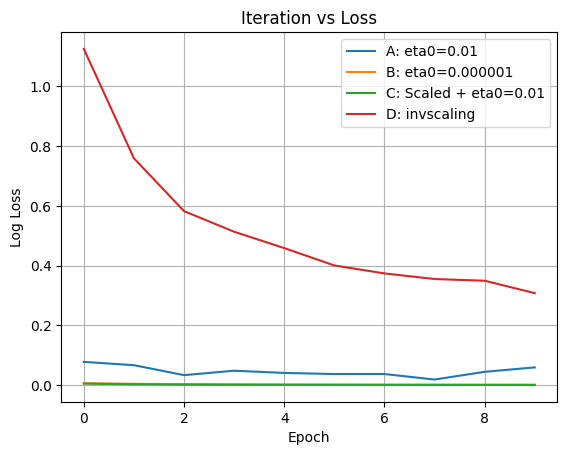

In [16]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import log_loss
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

def track_loss(x_train, y_train, learning_rate='constant', eta0=0.01, power_t=0.5, preprocess=False):
    if preprocess:
        scaler = StandardScaler()
        x_train = scaler.fit_transform(x_train)

    clf = SGDClassifier(loss='log_loss', penalty=None, random_state=10,
                        max_iter=1, learning_rate=learning_rate,
                        eta0=eta0, power_t=power_t, warm_start=True)

    losses = []
    for epoch in range(10):
        clf.fit(x_train, y_train)
        y_proba = clf.predict_proba(x_train)
        loss = log_loss(y_train, y_proba)
        losses.append(loss)

    return losses

# A. Constant learning rate = 0.01, no preprocessing
loss_A = track_loss(x_train_69, y_train_69, learning_rate='constant', eta0=0.01)

# B. Constant learning rate = 0.000001, no preprocessing
loss_B = track_loss(x_train_69, y_train_69, learning_rate='constant', eta0=0.000001)

# C. Constant learning rate = 0.01, with StandardScaler
loss_C = track_loss(x_train_69, y_train_69, learning_rate='constant', eta0=0.01, preprocess=True)

# D. Inverse scaling, power_t=1.0, no preprocessing
loss_D = track_loss(x_train_69, y_train_69, learning_rate='invscaling', eta0=0.01, power_t=1.0)

# Plotting
plt.plot(loss_A, label='A: eta0=0.01')
plt.plot(loss_B, label='B: eta0=0.000001')
plt.plot(loss_C, label='C: Scaled + eta0=0.01')
plt.plot(loss_D, label='D: invscaling')
plt.xlabel("Epoch")
plt.ylabel("Log Loss")
plt.title("Iteration vs Loss")
plt.legend()
plt.grid(True)
plt.show()
